In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

BASE = 'NASA_Cleaned_Dataset'
meta = pd.read_csv(f'{BASE}/metadata.csv')

# Capacity, Re, Rct are read as strings due to empty values - convert to numeric
meta['Capacity'] = pd.to_numeric(meta['Capacity'], errors='coerce')
meta['Re'] = pd.to_numeric(meta['Re'], errors='coerce')
meta['Rct'] = pd.to_numeric(meta['Rct'], errors='coerce')

print(f'Total records: {len(meta)}')
print(f'Columns: {list(meta.columns)}')
print(f'Battery IDs: {sorted(meta.battery_id.unique())}')
print(f'Operation types: {meta.type.value_counts().to_dict()}')
print(f'\nDtypes: Capacity={meta.Capacity.dtype}, Re={meta.Re.dtype}, Rct={meta.Rct.dtype}')
meta.head(10)

Total records: 7565
Columns: ['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']
Battery IDs: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']
Operation types: {'charge': 2815, 'discharge': 2794, 'impedance': 1956}

Dtypes: Capacity=float64, Re=float64, Rct=float64


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.056058,0.200970
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.053192,0.164734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN
5,charge,[2010. 7. 21. 22. 38. ...,4,B0047,5,6,00006.csv,NaN,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,NaN,NaN
7,charge,[2010. 7. 22. 3. 14. ...,4,B0047,7,8,00008.csv,NaN,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.483558,NaN,NaN
9,charge,[2010. 7. 22. 7. 50. ...,4,B0047,9,10,00010.csv,NaN,NaN,NaN


In [8]:
# per-battery summary: cycle counts, capacity range, temperature
summary = []
for bid in sorted(meta.battery_id.unique()):
    bm = meta[meta.battery_id == bid]
    dis = bm[bm.type == 'discharge']
    chg = bm[bm.type == 'charge']
    imp = bm[bm.type == 'impedance']
    caps = dis['Capacity'].dropna()
    re_vals = bm['Re'].dropna()
    rct_vals = bm['Rct'].dropna()
    summary.append({
        'battery_id': bid,
        'total_cycles': len(bm),
        'discharge': len(dis),
        'charge': len(chg),
        'impedance': len(imp),
        'cap_start': caps.iloc[0] if len(caps) > 0 else np.nan,
        'cap_end': caps.iloc[-1] if len(caps) > 0 else np.nan,
        'cap_min': caps.min() if len(caps) > 0 else np.nan,
        'cap_fade_pct': ((caps.iloc[0] - caps.iloc[-1]) / caps.iloc[0] * 100) if len(caps) > 1 else np.nan,
        'Re_start': re_vals.iloc[0] if len(re_vals) > 0 else np.nan,
        'Re_end': re_vals.iloc[-1] if len(re_vals) > 0 else np.nan,
        'Rct_start': rct_vals.iloc[0] if len(rct_vals) > 0 else np.nan,
        'Rct_end': rct_vals.iloc[-1] if len(rct_vals) > 0 else np.nan,
    })
summary_df = pd.DataFrame(summary)
print(f'Batteries with capacity data: {summary_df.cap_start.notna().sum()}')
summary_df

Batteries with capacity data: 34


,battery_id,total_cycles,discharge,charge,impedance,cap_start,cap_end,cap_min,cap_fade_pct,Re_start,Re_end,Rct_start,Rct_end
0,B0005,616,168,170,278,1.856487,1.325079,1.287453,28.624384,0.044669,0.050036,0.069456,0.074792
1,B0006,616,168,170,278,2.035338,1.185675,1.153818,41.745525,0.061234,0.073589,0.078542,0.099995
2,B0007,616,168,170,278,1.891052,1.432455,1.400455,24.250891,0.038168,0.067143,0.061581,0.093314
3,B0018,319,132,134,53,1.855005,1.341051,1.341051,27.706298,0.065158,0.066069,0.095554,0.088959
4,B0025,80,28,31,21,1.847011,1.767789,1.767789,4.289204,0.050642,0.049661,0.105922,0.082445
5,B0026,80,28,31,21,1.813250,1.768754,1.386337,2.453953,0.092718,0.090389,0.137872,0.117676
6,B0027,80,28,31,21,1.823308,1.770093,1.770093,2.918605,0.090840,0.099692,0.139167,0.124854
7,B0028,80,28,31,21,1.804685,1.717234,1.717234,4.845788,0.081411,0.079702,0.134353,0.113723
8,B0029,97,40,40,17,1.697507,1.612080,1.612080,5.032527,0.028340,0.028169,0.044702,0.041196
9,B0030,97,40,40,17,1.656071,1.562780,1.562780,5.633226,0.063418,0.064615,0.077259,0.075343


In [9]:
# fade stats
valid = summary_df[summary_df.cap_fade_pct.notna()]
print(f'Batteries with measurable capacity fade: {len(valid)}')
print(f'Capacity fade range: {valid.cap_fade_pct.min():.1f}% to {valid.cap_fade_pct.max():.1f}%')
print(f'\nBatteries reaching EOL (>30% fade): {(valid.cap_fade_pct >= 30).sum()}')
print(f'Batteries with >20% fade: {(valid.cap_fade_pct >= 20).sum()}')
print(f'\nTop 10 by fade:')
valid.sort_values('cap_fade_pct', ascending=False)[['battery_id', 'discharge', 'cap_start', 'cap_end', 'cap_fade_pct']].head(10)

Batteries with measurable capacity fade: 34
Capacity fade range: -1822.2% to 100.0%

Batteries reaching EOL (>30% fade): 7
Batteries with >20% fade: 14

Top 10 by fade:


,battery_id,discharge,cap_start,cap_end,cap_fade_pct
31,B0054,103,0.739935,0.000000,100.000000
30,B0053,56,1.069142,0.000000,100.000000
27,B0050,25,0.863145,0.278085,67.782328
22,B0045,72,1.081979,0.606948,43.903958
1,B0006,168,2.035338,1.185675,41.745525
23,B0046,72,1.728239,1.153804,33.238171
24,B0047,72,1.674305,1.156709,30.914085
0,B0005,168,1.856487,1.325079,28.624384
3,B0018,132,1.855005,1.341051,27.706298
25,B0048,72,1.657996,1.223127,26.228549


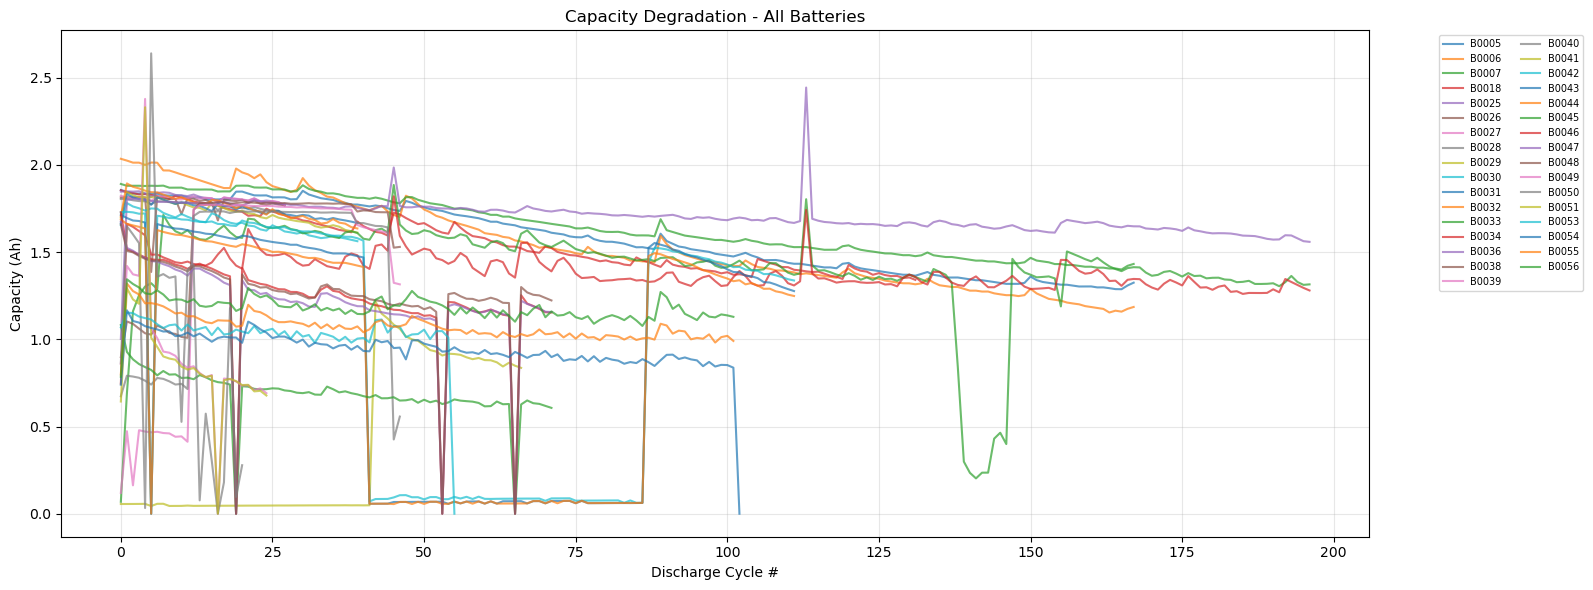

In [10]:
# capacity degradation curves for all batteries
fig, ax = plt.subplots(figsize=(16, 6))
for bid in sorted(meta.battery_id.unique()):
    dis = meta[(meta.battery_id == bid) & (meta.type == 'discharge')]
    caps = dis['Capacity'].dropna()
    if len(caps) > 5:
        ax.plot(range(len(caps)), caps.values, label=bid, alpha=0.7)
ax.set_xlabel('Discharge Cycle #')
ax.set_ylabel('Capacity (Ah)')
ax.set_title('Capacity Degradation - All Batteries')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

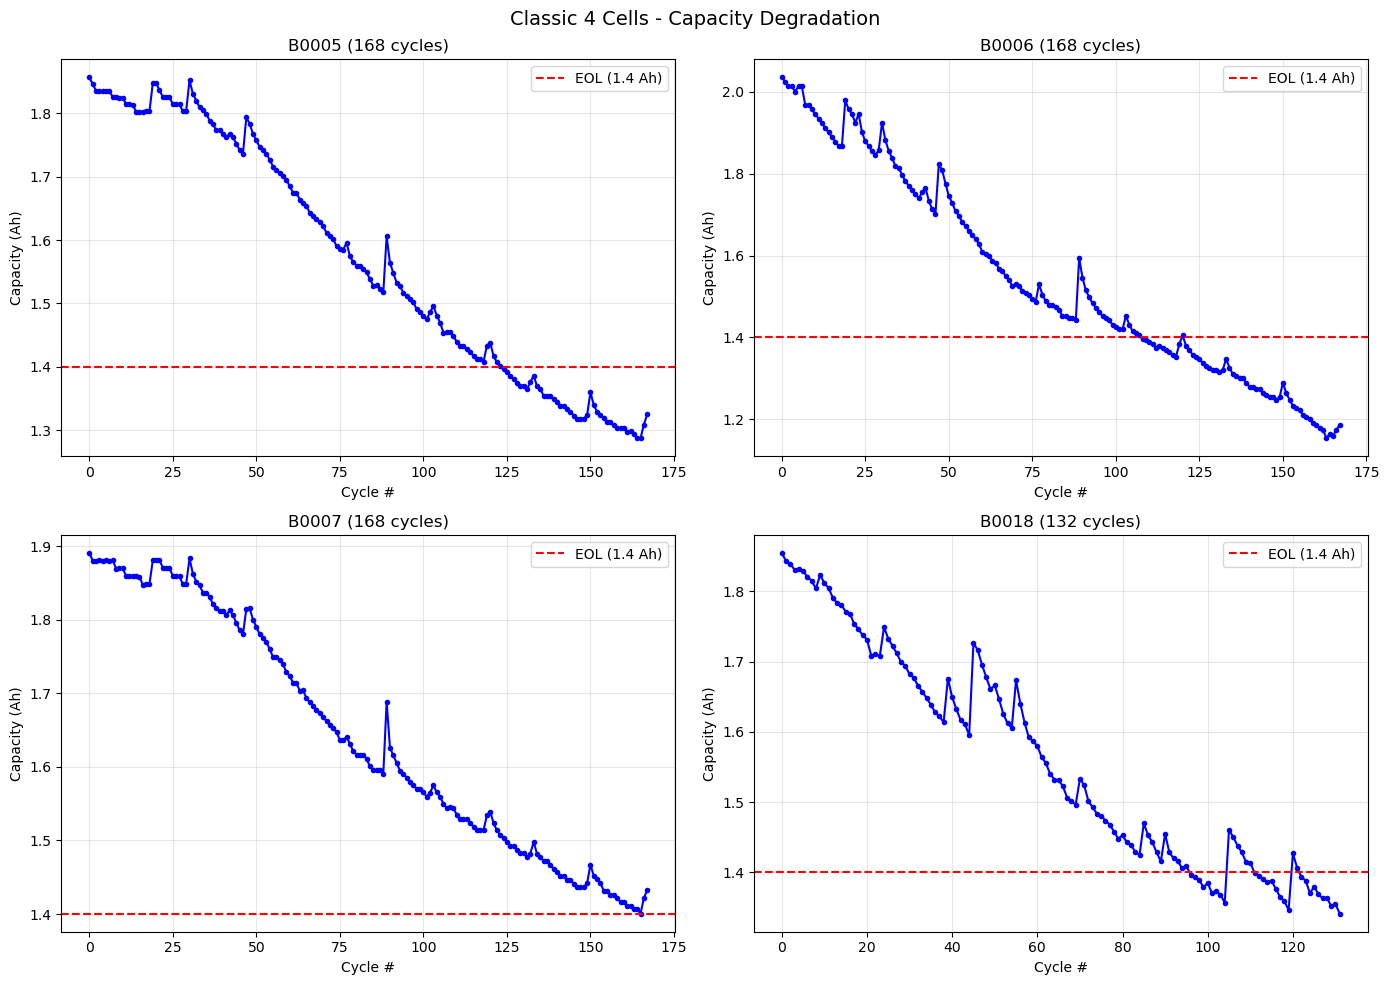

In [11]:
# focus on B0005, B0006, B0007, B0018 (the classic 4 cells)
classic = ['B0005', 'B0006', 'B0007', 'B0018']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, bid in zip(axes.flat, classic):
    dis = meta[(meta.battery_id == bid) & (meta.type == 'discharge')]
    caps = dis['Capacity'].dropna()
    ax.plot(range(len(caps)), caps.values, 'b-o', markersize=3)
    ax.axhline(y=1.4, color='r', linestyle='--', label='EOL (1.4 Ah)')
    ax.set_title(f'{bid} ({len(caps)} cycles)')
    ax.set_xlabel('Cycle #')
    ax.set_ylabel('Capacity (Ah)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Classic 4 Cells - Capacity Degradation', fontsize=14)
plt.tight_layout()
plt.show()

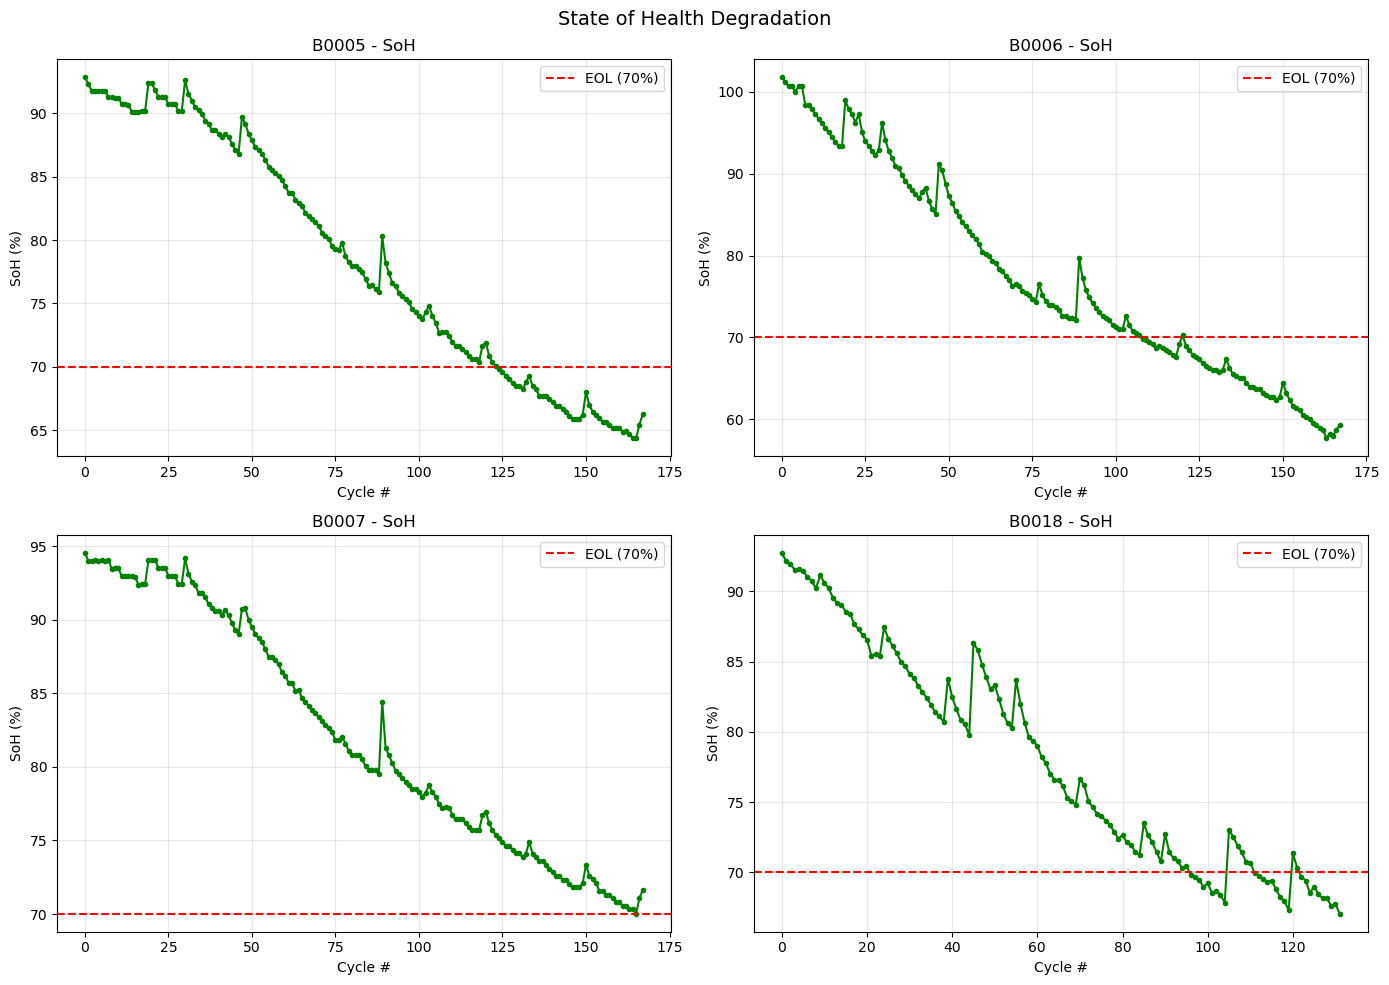

In [12]:
# SoH computation: SoH = Current_Capacity / Rated_Capacity * 100
# rated capacity = 2.0 Ah for the classic cells
RATED_CAPACITY = 2.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, bid in zip(axes.flat, classic):
    dis = meta[(meta.battery_id == bid) & (meta.type == 'discharge')]
    caps = dis['Capacity'].dropna()
    soh = caps.values / RATED_CAPACITY * 100
    ax.plot(range(len(soh)), soh, 'g-o', markersize=3)
    ax.axhline(y=70, color='r', linestyle='--', label='EOL (70%)')
    ax.set_title(f'{bid} - SoH')
    ax.set_xlabel('Cycle #')
    ax.set_ylabel('SoH (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('State of Health Degradation', fontsize=14)
plt.tight_layout()
plt.show()

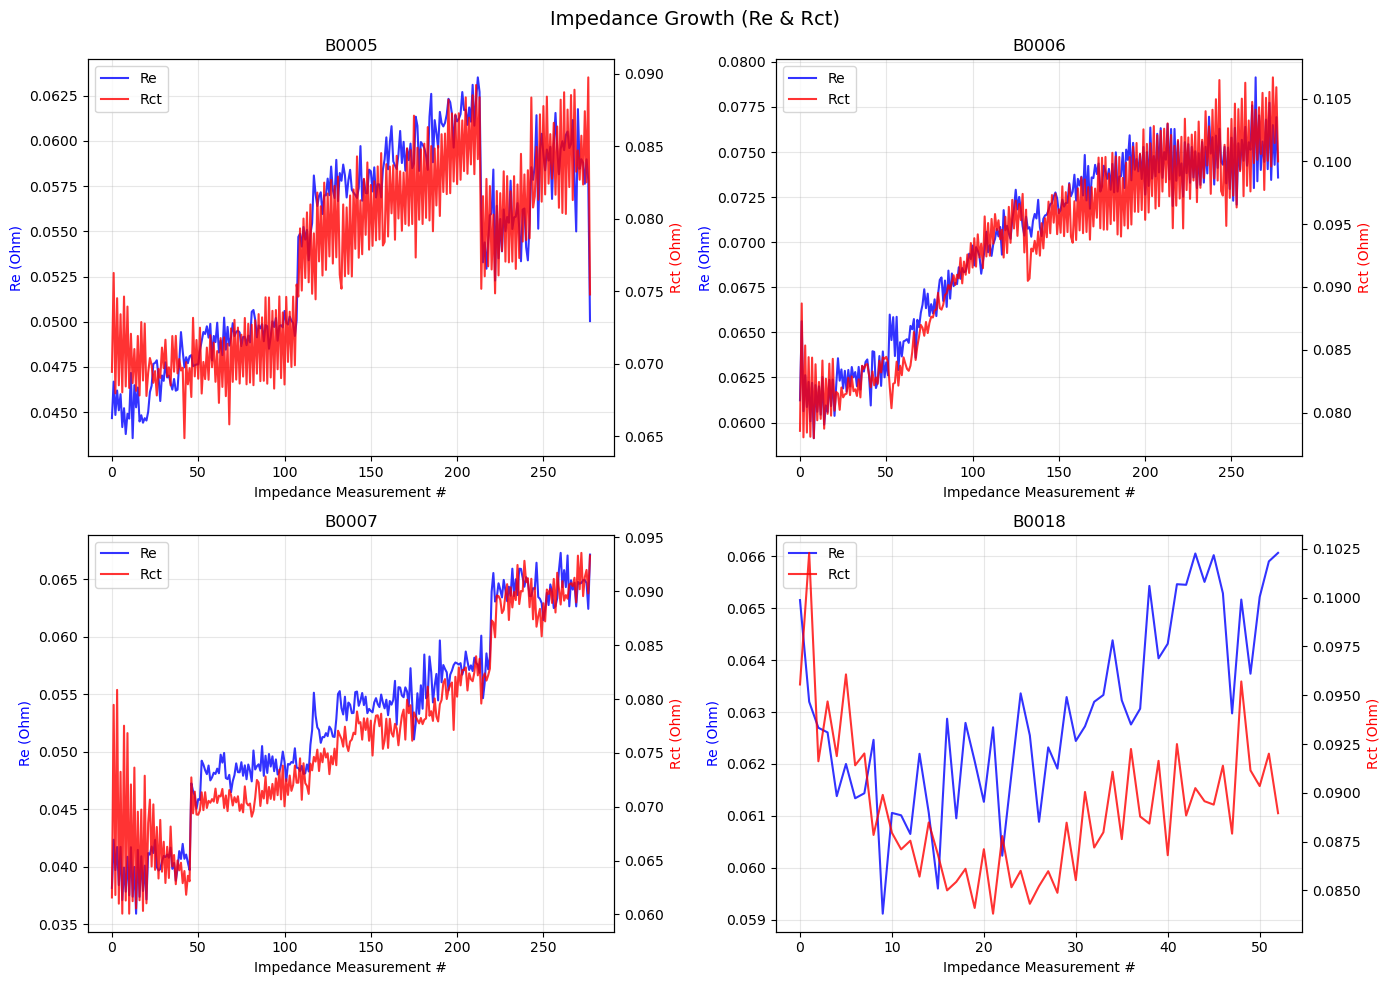

In [13]:
# impedance trends (Re and Rct) for the classic 4
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, bid in zip(axes.flat, classic):
    imp = meta[(meta.battery_id == bid) & (meta.type == 'impedance')]
    re = imp['Re'].dropna()
    rct = imp['Rct'].dropna()
    ax2 = ax.twinx()
    l1, = ax.plot(range(len(re)), re.values, 'b-', label='Re', alpha=0.8)
    l2, = ax2.plot(range(len(rct)), rct.values, 'r-', label='Rct', alpha=0.8)
    ax.set_title(f'{bid}')
    ax.set_xlabel('Impedance Measurement #')
    ax.set_ylabel('Re (Ohm)', color='b')
    ax2.set_ylabel('Rct (Ohm)', color='r')
    ax.legend(handles=[l1, l2], loc='upper left')
    ax.grid(True, alpha=0.3)
plt.suptitle('Impedance Growth (Re & Rct)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# look at a single discharge cycle's raw data
sample_dis = meta[(meta.battery_id == 'B0005') & (meta.type == 'discharge')].iloc[0]
sample_df = pd.read_csv(f"{BASE}/data/{sample_dis['filename']}")
print(f"Battery: {sample_dis['battery_id']}, Cycle: {sample_dis['test_id']}, Capacity: {sample_dis['Capacity']:.4f} Ah")
print(f"Columns: {list(sample_df.columns)}")
print(f"Samples: {len(sample_df)}, Duration: {sample_df['Time'].max():.1f}s")
sample_df.describe()

Battery: B0005, Cycle: 1, Capacity: 1.8565 Ah
Columns: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time']
Samples: 197, Duration: 3690.2s


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,3.529829,-1.818702,32.572328,-1.805570,2.404944,1812.087497
std,0.236558,0.595058,3.495804,0.591217,0.796974,1069.272600
min,2.612467,-2.018015,24.325993,-1.998400,0.000000,0.000000
25%,3.418746,-2.013447,30.422589,-1.998200,2.498000,891.812000
50%,3.529903,-2.012427,32.865786,-1.998200,2.610000,1796.328000
75%,3.685214,-2.011144,35.095568,-1.998200,2.765000,2724.203000
max,4.191492,0.000729,38.982181,-0.000400,4.206000,3690.234000


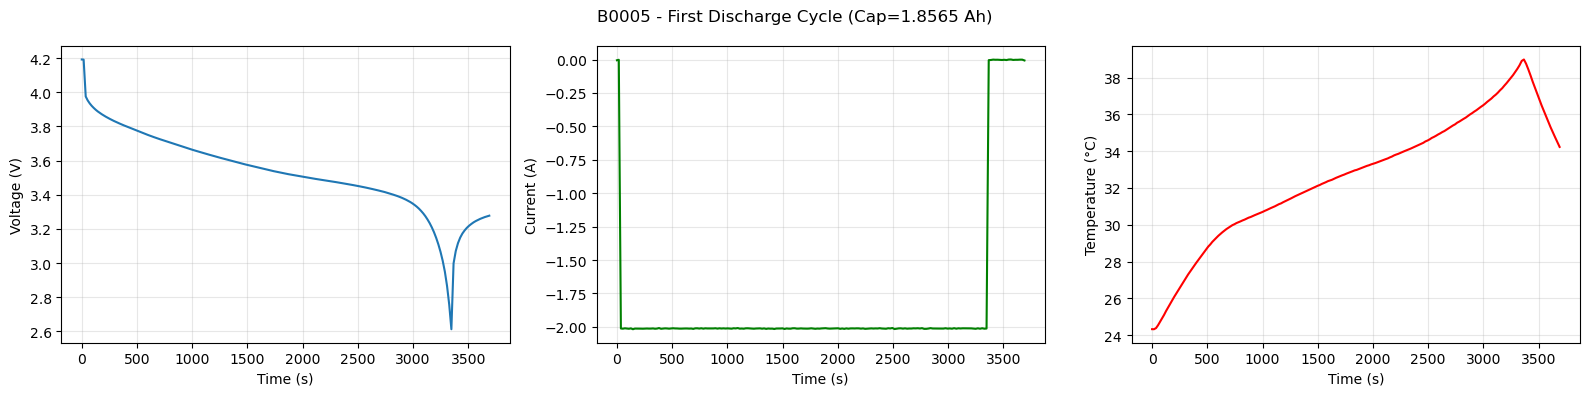

In [15]:
# plot a single discharge cycle
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(sample_df['Time'], sample_df['Voltage_measured'])
axes[0].set_ylabel('Voltage (V)')
axes[0].set_xlabel('Time (s)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sample_df['Time'], sample_df['Current_measured'], color='green')
axes[1].set_ylabel('Current (A)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(sample_df['Time'], sample_df['Temperature_measured'], color='red')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"B0005 - First Discharge Cycle (Cap={sample_dis['Capacity']:.4f} Ah)")
plt.tight_layout()
plt.show()

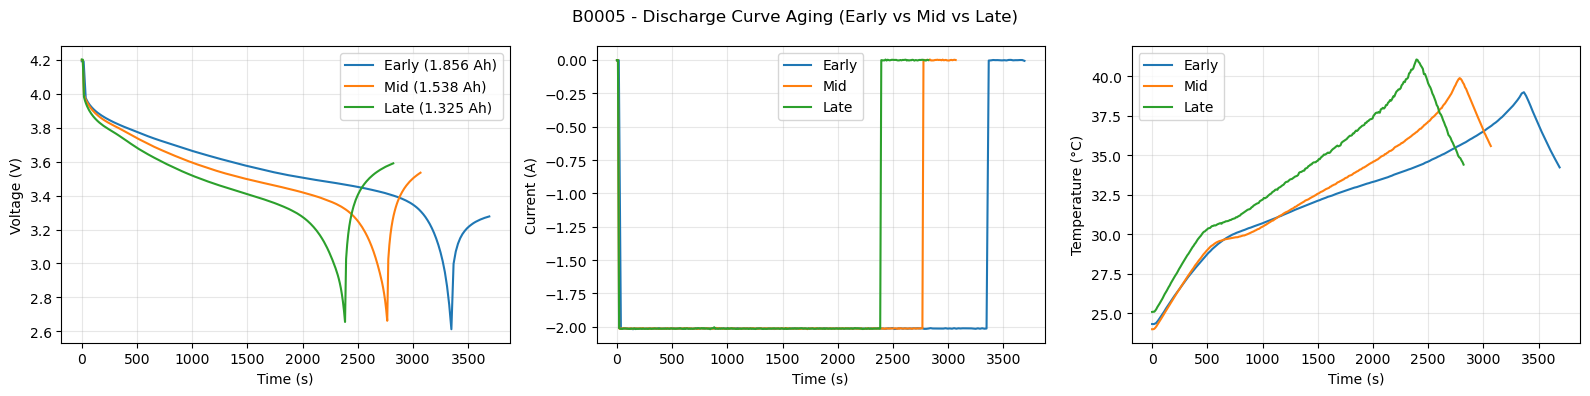

In [16]:
# compare early vs late discharge curves for B0005
b5_dis = meta[(meta.battery_id == 'B0005') & (meta.type == 'discharge') & (meta.Capacity.notna())]
early_file = b5_dis.iloc[0]['filename']
mid_file = b5_dis.iloc[len(b5_dis)//2]['filename']
late_file = b5_dis.iloc[-1]['filename']

early = pd.read_csv(f'{BASE}/data/{early_file}')
mid = pd.read_csv(f'{BASE}/data/{mid_file}')
late = pd.read_csv(f'{BASE}/data/{late_file}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for df, label, cap in [(early, 'Early', b5_dis.iloc[0]['Capacity']),
                        (mid, 'Mid', b5_dis.iloc[len(b5_dis)//2]['Capacity']),
                        (late, 'Late', b5_dis.iloc[-1]['Capacity'])]:
    axes[0].plot(df['Time'], df['Voltage_measured'], label=f'{label} ({cap:.3f} Ah)')
    axes[1].plot(df['Time'], df['Current_measured'], label=f'{label}')
    axes[2].plot(df['Time'], df['Temperature_measured'], label=f'{label}')

for ax, ylabel in zip(axes, ['Voltage (V)', 'Current (A)', 'Temperature (°C)']):
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Time (s)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('B0005 - Discharge Curve Aging (Early vs Mid vs Late)')
plt.tight_layout()
plt.show()

In [17]:
# extract per-cycle features from discharge data for ML
def extract_cycle_features(meta_df, base_path, battery_id):
    dis = meta_df[(meta_df.battery_id == battery_id) & (meta_df.type == 'discharge') & (meta_df.Capacity.notna())]
    imp = meta_df[(meta_df.battery_id == battery_id) & (meta_df.type == 'impedance')]
    
    features = []
    for idx, (_, row) in enumerate(dis.iterrows()):
        try:
            df = pd.read_csv(f"{base_path}/data/{row['filename']}")
        except:
            continue
        
        # voltage features
        v = df['Voltage_measured']
        # current features
        i = df['Current_measured']
        # temperature features
        t = df['Temperature_measured']
        # time
        time = df['Time']
        
        feat = {
            'battery_id': battery_id,
            'cycle': idx,
            'capacity': row['Capacity'],
            # voltage stats
            'v_mean': v.mean(),
            'v_std': v.std(),
            'v_min': v.min(),
            'v_max': v.max(),
            'v_range': v.max() - v.min(),
            # current stats
            'i_mean': i.mean(),
            'i_std': i.std(),
            'i_min': i.min(),
            'i_max': i.max(),
            # temperature stats
            't_mean': t.mean(),
            't_std': t.std(),
            't_max': t.max(),
            't_rise': t.max() - t.iloc[0],
            # discharge time
            'discharge_time': time.max(),
            # energy proxy: integral of V*I over time
            'energy': np.trapz(v.values * np.abs(i.values), time.values) / 3600,
        }
        
        # add impedance from closest prior measurement
        prior_imp = imp[imp.uid < row['uid']]
        if len(prior_imp) > 0:
            last_imp = prior_imp.iloc[-1]
            feat['Re'] = last_imp['Re'] if pd.notna(last_imp['Re']) else np.nan
            feat['Rct'] = last_imp['Rct'] if pd.notna(last_imp['Rct']) else np.nan
        else:
            feat['Re'] = np.nan
            feat['Rct'] = np.nan
        
        features.append(feat)
    
    return pd.DataFrame(features)

# extract for the classic 4
all_features = []
for bid in classic:
    bf = extract_cycle_features(meta, BASE, bid)
    all_features.append(bf)
    print(f'{bid}: {len(bf)} cycles, capacity {bf.capacity.iloc[0]:.3f} → {bf.capacity.iloc[-1]:.3f} Ah')

features_df = pd.concat(all_features, ignore_index=True)
print(f'\nTotal feature rows (classic 4): {len(features_df)}')
features_df.head()

B0005: 168 cycles, capacity 1.856 → 1.325 Ah
B0006: 168 cycles, capacity 2.035 → 1.186 Ah
B0007: 168 cycles, capacity 1.891 → 1.432 Ah
B0018: 132 cycles, capacity 1.855 → 1.341 Ah

Total feature rows (classic 4): 636


,battery_id,cycle,capacity,v_mean,v_std,v_min,v_max,v_range,i_mean,i_std,i_min,i_max,t_mean,t_std,t_max,t_rise,discharge_time,energy,Re,Rct
0,B0005,0,1.856487,3.529829,0.236558,2.612467,4.191492,1.579024,-1.818702,0.595058,-2.018015,0.000729,32.572328,3.495804,38.982181,14.652147,3690.234,6.608778,NaN,NaN
1,B0005,1,1.846327,3.537320,0.235366,2.587209,4.189773,1.602564,-1.817560,0.596704,-2.016821,0.002927,32.725235,3.435509,39.033398,14.335646,3672.344,6.586345,NaN,NaN
2,B0005,2,1.835349,3.543737,0.228111,2.651917,4.188187,1.536270,-1.816487,0.598033,-2.016574,0.001484,32.642862,3.388174,38.818797,14.084531,3651.641,6.555683,NaN,NaN
3,B0005,3,1.835263,3.543666,0.233347,2.592948,4.188461,1.595513,-1.825589,0.584972,-2.015936,0.001547,32.514876,3.395306,38.762305,14.108068,3631.563,6.554829,NaN,NaN
4,B0005,4,1.834646,3.542343,0.237301,2.547420,4.188299,1.640879,-1.826114,0.584978,-2.017426,0.001701,32.382349,3.404667,38.665393,14.140596,3629.172,6.552232,NaN,NaN


In [18]:
# extract for ALL batteries
all_features_full = []
for bid in sorted(meta.battery_id.unique()):
    bf = extract_cycle_features(meta, BASE, bid)
    if len(bf) > 5:
        all_features_full.append(bf)
        print(f'{bid}: {len(bf)} cycles, cap {bf.capacity.iloc[0]:.3f} → {bf.capacity.iloc[-1]:.3f} Ah, fade {(1-bf.capacity.iloc[-1]/bf.capacity.iloc[0])*100:.1f}%')

full_features_df = pd.concat(all_features_full, ignore_index=True)
print(f'\nTotal feature rows (all batteries): {len(full_features_df)}')
print(f'Batteries included: {full_features_df.battery_id.nunique()}')

B0005: 168 cycles, cap 1.856 → 1.325 Ah, fade 28.6%
B0006: 168 cycles, cap 2.035 → 1.186 Ah, fade 41.7%
B0007: 168 cycles, cap 1.891 → 1.432 Ah, fade 24.3%
B0018: 132 cycles, cap 1.855 → 1.341 Ah, fade 27.7%
B0025: 28 cycles, cap 1.847 → 1.768 Ah, fade 4.3%
B0026: 28 cycles, cap 1.813 → 1.769 Ah, fade 2.5%
B0027: 28 cycles, cap 1.823 → 1.770 Ah, fade 2.9%
B0028: 28 cycles, cap 1.805 → 1.717 Ah, fade 4.8%
B0029: 40 cycles, cap 1.698 → 1.612 Ah, fade 5.0%
B0030: 40 cycles, cap 1.656 → 1.563 Ah, fade 5.6%
B0031: 40 cycles, cap 1.667 → 1.667 Ah, fade -0.0%
B0032: 40 cycles, cap 1.705 → 1.636 Ah, fade 4.1%
B0033: 197 cycles, cap 0.068 → 1.315 Ah, fade -1822.2%
B0034: 197 cycles, cap 0.746 → 1.280 Ah, fade -71.6%
B0036: 197 cycles, cap 1.002 → 1.559 Ah, fade -55.6%
B0038: 47 cycles, cap 0.898 → 1.530 Ah, fade -70.4%
B0039: 47 cycles, cap 0.119 → 1.315 Ah, fade -1005.0%
B0040: 47 cycles, cap 0.673 → 0.557 Ah, fade 17.3%
B0041: 67 cycles, cap 0.056 → 0.836 Ah, fade -1403.9%
B0042: 112 cycles, 

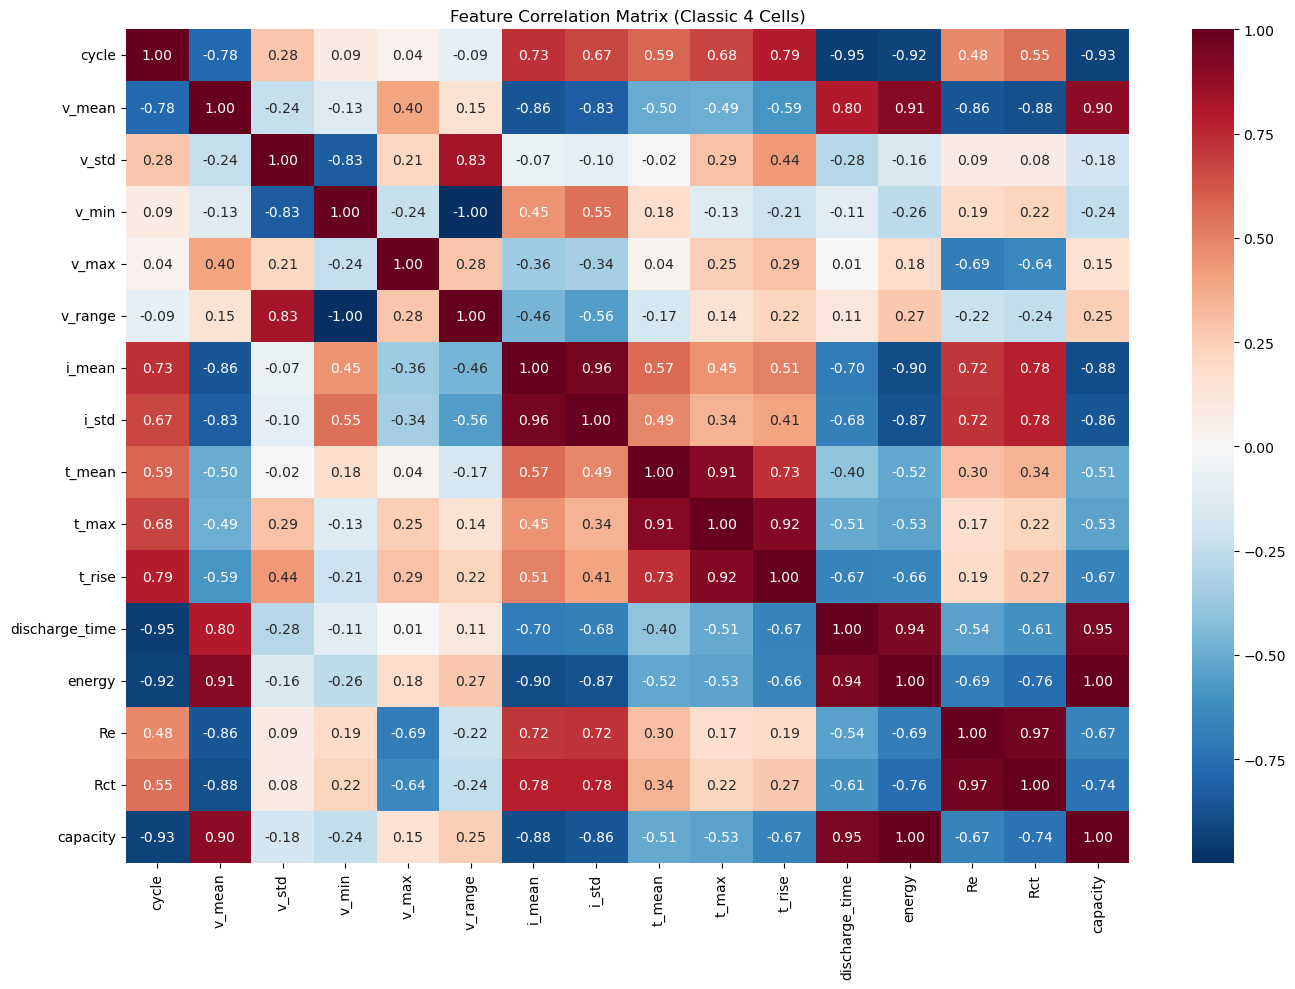

Top feature correlations with capacity:
  energy              : +0.9989
  discharge_time      : +0.9523
  cycle               : -0.9287
  v_mean              : +0.8963
  i_mean              : -0.8836
  i_std               : -0.8555
  Rct                 : -0.7403
  Re                  : -0.6703
  t_rise              : -0.6675
  t_max               : -0.5342
  t_mean              : -0.5096
  v_range             : +0.2460
  v_min               : -0.2425
  v_std               : -0.1830
  v_max               : +0.1533


In [19]:
# correlation matrix of features vs capacity
corr_cols = ['cycle', 'v_mean', 'v_std', 'v_min', 'v_max', 'v_range',
             'i_mean', 'i_std', 't_mean', 't_max', 't_rise',
             'discharge_time', 'energy', 'Re', 'Rct', 'capacity']
corr = features_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix (Classic 4 Cells)')
plt.tight_layout()
plt.show()

# top correlations with capacity
cap_corr = corr['capacity'].drop('capacity').sort_values(key=abs, ascending=False)
print('Top feature correlations with capacity:')
for feat, val in cap_corr.items():
    print(f'  {feat:20s}: {val:+.4f}')

In [20]:
# RUL computation and distribution
# RUL = cycles remaining until capacity drops below EOL threshold
EOL_THRESHOLD = 1.4  # Ah (30% fade from 2.0 Ah rated)

for bid in classic:
    bf = features_df[features_df.battery_id == bid]
    total = len(bf)
    eol_idx = bf[bf.capacity <= EOL_THRESHOLD].index
    if len(eol_idx) > 0:
        eol_cycle = bf.loc[eol_idx[0], 'cycle']
        print(f'{bid}: EOL at cycle {eol_cycle}/{total-1}, final capacity {bf.capacity.iloc[-1]:.3f} Ah')
    else:
        print(f'{bid}: did not reach EOL, final capacity {bf.capacity.iloc[-1]:.3f} Ah')

# add RUL column (cycles remaining)
def add_rul(df, eol_threshold=EOL_THRESHOLD):
    result = []
    for bid in df.battery_id.unique():
        bdf = df[df.battery_id == bid].copy()
        eol_rows = bdf[bdf.capacity <= eol_threshold]
        if len(eol_rows) > 0:
            eol_cycle = eol_rows.iloc[0]['cycle']
        else:
            eol_cycle = bdf['cycle'].max()  # use last cycle as proxy
        bdf['RUL'] = eol_cycle - bdf['cycle']
        bdf['SoH'] = bdf['capacity'] / RATED_CAPACITY * 100
        result.append(bdf)
    return pd.concat(result, ignore_index=True)

features_df = add_rul(features_df)
print(f'\nRUL range: {features_df.RUL.min()} to {features_df.RUL.max()} cycles')
print(f'SoH range: {features_df.SoH.min():.1f}% to {features_df.SoH.max():.1f}%')

B0005: EOL at cycle 124/167, final capacity 1.325 Ah
B0006: EOL at cycle 108/167, final capacity 1.186 Ah
B0007: did not reach EOL, final capacity 1.432 Ah
B0018: EOL at cycle 96/131, final capacity 1.341 Ah

RUL range: -59 to 167 cycles
SoH range: 57.7% to 101.8%


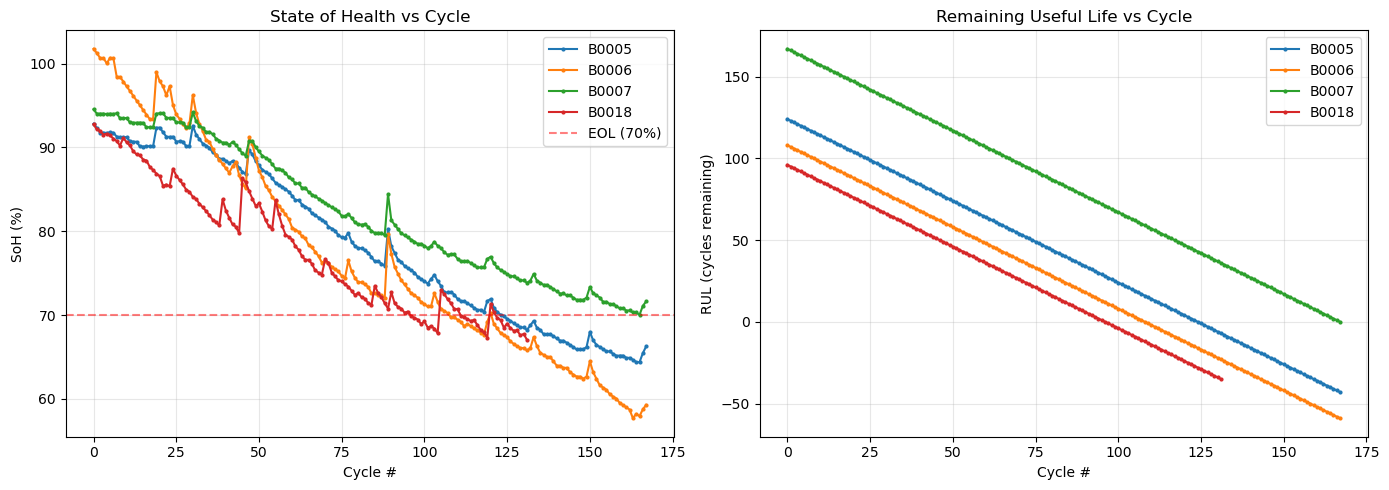

In [21]:
# SoH and RUL distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for bid in classic:
    bf = features_df[features_df.battery_id == bid]
    axes[0].plot(bf['cycle'], bf['SoH'], '-o', markersize=2, label=bid)
    axes[1].plot(bf['cycle'], bf['RUL'], '-o', markersize=2, label=bid)

axes[0].axhline(y=70, color='r', linestyle='--', alpha=0.5, label='EOL (70%)')
axes[0].set_xlabel('Cycle #')
axes[0].set_ylabel('SoH (%)')
axes[0].set_title('State of Health vs Cycle')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Cycle #')
axes[1].set_ylabel('RUL (cycles remaining)')
axes[1].set_title('Remaining Useful Life vs Cycle')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# dataset verdict
print('='*60)
print('NASA Battery Dataset - Summary')
print('='*60)
print(f'Total batteries: {meta.battery_id.nunique()}')
print(f'Total records: {len(meta)}')
print(f'Classic 4 cells (B0005-B0018): {len(features_df)} discharge cycles with features')
print(f'Full dataset: {len(full_features_df)} discharge cycles with features')
print(f'\nFeatures per cycle: {len([c for c in features_df.columns if c not in ["battery_id"]])}')
print(f'  - Voltage: mean, std, min, max, range')
print(f'  - Current: mean, std, min, max')
print(f'  - Temperature: mean, std, max, rise')
print(f'  - Time: discharge duration')
print(f'  - Energy: V*I integral')
print(f'  - Impedance: Re, Rct (from EIS)')
print(f'\nTargets:')
print(f'  - SoH: {features_df.SoH.min():.1f}% to {features_df.SoH.max():.1f}%')
print(f'  - RUL: {features_df.RUL.min()} to {features_df.RUL.max()} cycles')
print(f'  - Capacity: {features_df.capacity.min():.3f} to {features_df.capacity.max():.3f} Ah')
print(f'\nDataset is SUITABLE for SoH + RUL prediction benchmarking.')
print(f'Clear degradation trends, multiple batteries, impedance features available.')

NASA Battery Dataset - Summary
Total batteries: 34
Total records: 7565
Classic 4 cells (B0005-B0018): 636 discharge cycles with features
Full dataset: 2765 discharge cycles with features

Features per cycle: 21
  - Voltage: mean, std, min, max, range
  - Current: mean, std, min, max
  - Temperature: mean, std, max, rise
  - Time: discharge duration
  - Energy: V*I integral
  - Impedance: Re, Rct (from EIS)

Targets:
  - SoH: 57.7% to 101.8%
  - RUL: -59 to 167 cycles
  - Capacity: 1.154 to 2.035 Ah

Dataset is SUITABLE for SoH + RUL prediction benchmarking.
Clear degradation trends, multiple batteries, impedance features available.
